# Vector-less Graph RAG

In traditional RAG, we split documents into chunks and use an **embedding model** to store them in a vector database. During retrieval, we find chunks semantically similar to the question using vector math.

**Graph RAG** takes a different approach. It builds a **Knowledge Graph** of entities (nodes) and their relationships (edges) extracted from the text. 

In a **Vector-less Graph RAG**, we completely eliminate the embedding model and vector database. Instead, we rely entirely on the graph structure:
1. **Extraction:** Use an LLM to extract entities and relations from the text to build the graph.
2. **Retrieval:** Extract entities from the user's question and find matching nodes in the graph using keyword/string matching (no vectors).
3. **Context:** Traverse the graph to find neighboring nodes and relationships, forming a "subgraph" of context.
4. **Generation:** Pass this graph context to the LLM to answer the question.

### 1. Setup and Dependencies
We need `networkx` to build and manage our graph in memory. We'll use the same `llama3.2:3b` model for both extracting the graph and answering the questions.

In [ ]:
#!pip install networkx matplotlib pypdf langchain_ollama langchain_community


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import networkx as nx
import matplotlib.pyplot as plt
from langchain_ollama import OllamaLLM
from langchain_community.document_loaders import PyPDFLoader
import json
import re
# qwen3.5:9b
#llama3.2:3b
print("🔧 Loading model...")
llm = OllamaLLM(model="qwen3.5:9b")
print("✅ Model ready")

🔧 Loading model...
✅ Model ready


### 2. Load the Data
We load **page 0 and page 1** from the Attention paper PDF and combine them into a single text block. Processing more pages gives the LLM more facts to extract into the Knowledge Graph, resulting in richer retrieval.

In [3]:
loader = PyPDFLoader("NIPS-2017-attention-is-all-you-need-Paper.pdf")
pages = loader.load()

# Combine page 0 and page 1 into a single text block
text_data = pages[0].page_content + "\n" + pages[1].page_content
print(f"📄 Total characters from pages 0 & 1: {len(text_data)}")
print(f"\n--- Page 0 preview ---\n{pages[0].page_content[:300]}\n")
print(f"--- Page 1 preview ---\n{pages[1].page_content[:300]}\n")

📄 Total characters from pages 0 & 1: 7157

--- Page 0 preview ---
Attention Is All You Need
Ashish Vaswani∗
Google Brain
avaswani@google.com
Noam Shazeer∗
Google Brain
noam@google.com
Niki Parmar∗
Google Research
nikip@google.com
Jakob Uszkoreit∗
Google Research
usz@google.com
Llion Jones∗
Google Research
llion@google.com
Aidan N. Gomez∗†
University of Toronto
aid

--- Page 1 preview ---
Recurrent models typically factor computation along the symbol positions of the input and output
sequences. Aligning the positions to steps in computation time, they generate a sequence of hidden
statesht, as a function of the previous hidden stateht−1 and the input for positiont. This inherently
se



### 3. Knowledge Graph Extraction
Here we ask the LLM to read the text and extract triplets: `(Subject, Relation, Object)`. 
These triplets represent the facts in the text.

In [4]:
extraction_prompt = """
You are an expert data extractor. Your task is to extract relationships between entities in the given text.
Infer latent relationships where obvious (e.g., if a list of names appears under a title, they are likely 'authors' of the 'paper').
Format the output as a JSON list of objects, where each object has three keys: "subject", "relation", "object".
Only output valid JSON. Do not include any other text.

Example:
Text: "Attention Is All You Need\nAshish Vaswani\nGoogle Brain"
Output:
[
  {{"subject": "Ashish Vaswani", "relation": "author of", "object": "Attention Is All You Need"}},
  {{"subject": "Ashish Vaswani", "relation": "affiliated with", "object": "Google Brain"}}
]

Text:
{text}

Output:
"""

def extract_triplets(text):
    print("⏳ Extracting triplets using LLM...")
    response = llm.invoke(extraction_prompt.format(text=text))
    
    # Simple regex to extract JSON array if the LLM adds markdown formatting
    match = re.search(r'\[.*\]', response, re.DOTALL)
    if match:
        try:
            return json.loads(match.group(0))
        except:
            pass
    return []

from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=1500,
    chunk_overlap=150
)
chunks = splitter.split_text(text_data)
print(f"📦 Split text into {len(chunks)} chunks for LLM processing...")

all_triplets = []
for i, chunk in enumerate(chunks):
    print(f"\n--- Chunk {i+1}/{len(chunks)} ---")
    triplets = extract_triplets(chunk)
    all_triplets.extend(triplets)

print(f"\n✅ Extracted total {len(all_triplets)} relations.")
for t in all_triplets[:5]:
    print(t)

# Update the variable name for the next cell that builds the graph
triplets = all_triplets


📦 Split text into 6 chunks for LLM processing...

--- Chunk 1/6 ---
⏳ Extracting triplets using LLM...

--- Chunk 2/6 ---
⏳ Extracting triplets using LLM...

--- Chunk 3/6 ---
⏳ Extracting triplets using LLM...

--- Chunk 4/6 ---
⏳ Extracting triplets using LLM...

--- Chunk 5/6 ---
⏳ Extracting triplets using LLM...

--- Chunk 6/6 ---
⏳ Extracting triplets using LLM...

✅ Extracted total 51 relations.
{'subject': 'Ashish Vaswani', 'relation': 'author of', 'object': 'Attention Is All You Need'}
{'subject': 'Ashish Vaswani', 'relation': 'affiliated with', 'object': 'Google Brain'}
{'subject': 'Noam Shazeer', 'relation': 'author of', 'object': 'Attention Is All You Need'}
{'subject': 'Noam Shazeer', 'relation': 'affiliated with', 'object': 'Google Brain'}
{'subject': 'Niki Parmar', 'relation': 'author of', 'object': 'Attention Is All You Need'}


### 4. Build and Visualize the Graph
We use `networkx` to create a directed graph. Nodes are the subjects and objects. Directed edges are the relations connecting them.

✅ Graph built with 66 nodes and 51 edges.


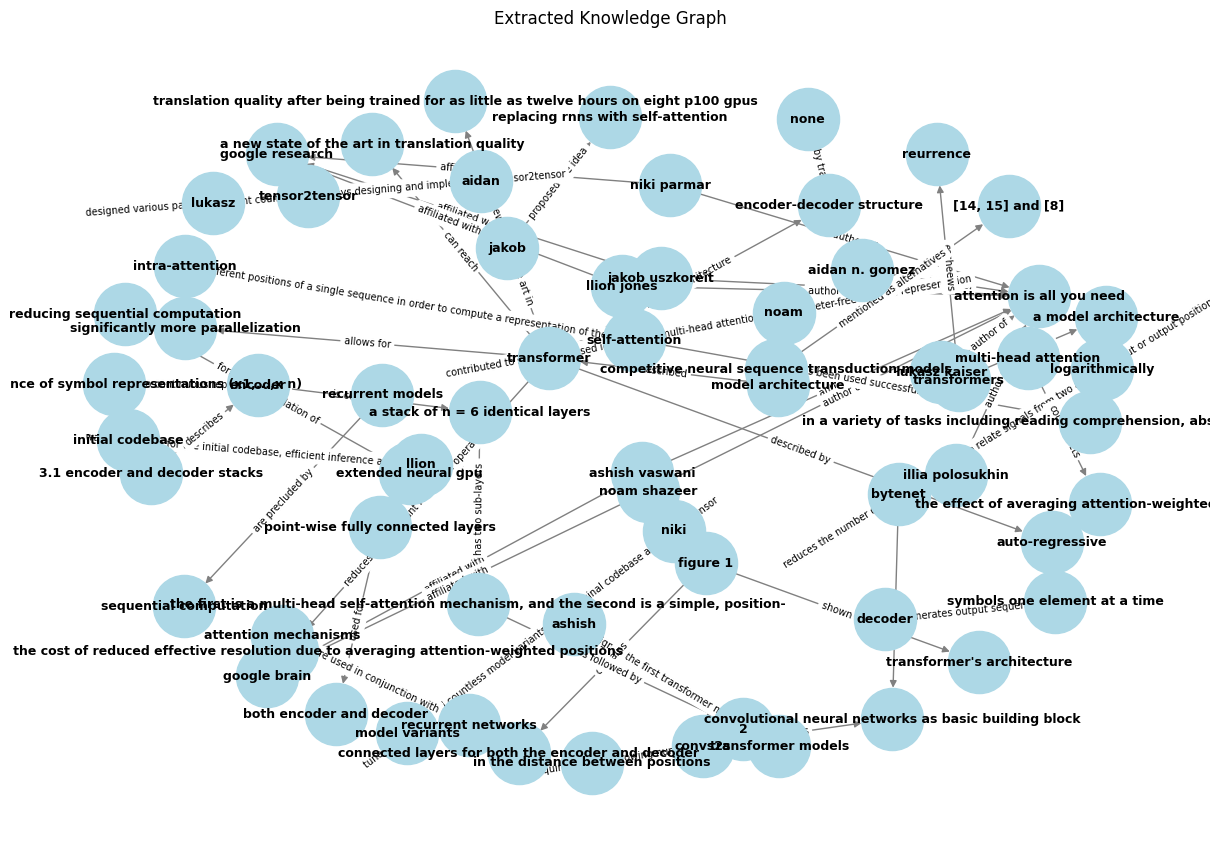

In [5]:
G = nx.DiGraph()

for triplet in triplets:
    subj = triplet.get("subject", "").strip().lower()
    obj = triplet.get("object", "").strip().lower()
    rel = triplet.get("relation", "").strip().lower()
    
    if subj and obj and rel:
        G.add_node(subj)
        G.add_node(obj)
        G.add_edge(subj, obj, label=rel)

print(f"✅ Graph built with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

# Visualization
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42, k=0.5) # k controls node spacing
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_size=9, font_weight='bold', edge_color='gray')
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)
plt.title("Extracted Knowledge Graph")
plt.show()

### 5. Vector-less Retrieval
To retrieve context without vectors, we:
1. Extract the main entities from the user's query.
2. Perform keyword/string matching to find these entities in our graph nodes.
3. Extract the **1-hop subgraph** (immediate neighbors and edges) around the matched nodes.
This subgraph represents the retrieved facts!

In [6]:
node_match_prompt = """
You are an AI assisting in a graph search.
Given a user's question and a list of available graph nodes, identify which nodes are most relevant to answering the question.
Return ONLY a comma-separated list of the exact node names from the provided list. Do not explain.

Question: {question}
Available Nodes: {nodes}
Relevant Nodes:
"""

def retrieve_context(question, graph):
    print(f"❓ Question: {question}")
    
    # 1. Ask LLM to select relevant nodes from the graph's node list
    all_nodes = list(graph.nodes())
    nodes_str = ", ".join(all_nodes)
    
    print("⏳ Finding relevant nodes using LLM...")
    response = llm.invoke(node_match_prompt.format(question=question, nodes=nodes_str))
    matched_nodes = [n.strip() for n in response.split(',') if n.strip() in all_nodes]
    
    print(f"🎯 Matched Graph Nodes: {matched_nodes}")
    
    # 2. Extract subgraph facts (1-hop)
    context_facts = []
    for node in matched_nodes:
        for neighbor in graph.successors(node):
            rel = graph.edges[node, neighbor]['label']
            context_facts.append(f"{node} --[{rel}]--> {neighbor}")
        for neighbor in graph.predecessors(node):
            rel = graph.edges[neighbor, node]['label']
            context_facts.append(f"{neighbor} --[{rel}]--> {node}")
            
    context_facts = list(set(context_facts))
    
    print(f"📋 Retrieved {len(context_facts)} graph facts")
    for fact in context_facts:
        print(f"  - {fact}")
        
    return "\n".join(context_facts)


### 6. Generation
We inject the retrieved graph facts into the prompt and ask the LLM to generate the final answer.

In [7]:
qa_prompt = """You are an expert AI research assistant.
Answer the question using ONLY the knowledge graph facts provided below.
Be direct and use the facts to form your answer.
If the answer is not in the facts, say "I don't have enough information in the graph to answer that."

Knowledge Graph Facts:
{context}

Question: {question}

Answer:"""

def ask_graph_rag(question, graph):
    context = retrieve_context(question, graph)
    
    if not context:
        print("\n🤖 Answer: I don't have enough information in the graph to answer that (No matching nodes found).\n")
        print("─"*60 + "\n")
        return
        
    prompt = qa_prompt.format(context=context, question=question)
    response = llm.invoke(prompt)
    
    print(f"\n🤖 Answer:\n{response}")
    print("\n" + "─"*60 + "\n")

# Let's ask a question!
ask_graph_rag("Who is affiliated with Google Brain?", G)

❓ Question: Who is affiliated with Google Brain?
⏳ Finding relevant nodes using LLM...
🎯 Matched Graph Nodes: ['google brain', 'noam shazeer', 'ashish vaswani']
📋 Retrieved 4 graph facts
  - ashish vaswani --[affiliated with]--> google brain
  - ashish vaswani --[author of]--> attention is all you need
  - noam shazeer --[affiliated with]--> google brain
  - noam shazeer --[author of]--> attention is all you need

🤖 Answer:
The individuals affiliated with Google Brain are:

* Ashish Vaswani
* Noam Shazeer

────────────────────────────────────────────────────────────



In [8]:
ask_graph_rag("What are the dominant sequence transduction models based on?", G)

❓ Question: What are the dominant sequence transduction models based on?
⏳ Finding relevant nodes using LLM...
🎯 Matched Graph Nodes: ['ashish vaswani', 'attention is all you need', 'noam shazeer', 'niki parmar', 'jakob uszkoreit', 'llion jones', 'aidan n. gomez', 'łukasz kaiser', 'illia polosukhin', 'noam', 'jakob', 'llion']
📋 Retrieved 16 graph facts
  - llion jones --[author of]--> attention is all you need
  - llion jones --[affiliated with]--> google research
  - niki parmar --[author of]--> attention is all you need
  - niki parmar --[affiliated with]--> google research
  - jakob uszkoreit --[author of]--> attention is all you need
  - jakob --[proposed the idea]--> replacing rnns with self-attention
  - ashish vaswani --[affiliated with]--> google brain
  - łukasz kaiser --[author of]--> attention is all you need
  - jakob uszkoreit --[affiliated with]--> google research
  - llion --[was responsible for the initial codebase, efficient inference and visualizations]--> initial cod

In [9]:
ask_graph_rag("What is difference between transformers and RNN?", G)

❓ Question: What is difference between transformers and RNN?
⏳ Finding relevant nodes using LLM...
🎯 Matched Graph Nodes: ['ashish vaswani', 'noam shazeer', 'jakob uszkoreit', 'niki parmar', 'illia polosukhin', 'transformers', 'attention is all you need', 'transformer models']
📋 Retrieved 15 graph facts
  - llion jones --[author of]--> attention is all you need
  - transformers --[escheews]--> reurrence
  - niki parmar --[author of]--> attention is all you need
  - niki parmar --[affiliated with]--> google research
  - jakob uszkoreit --[author of]--> attention is all you need
  - ashish vaswani --[affiliated with]--> google brain
  - jakob uszkoreit --[affiliated with]--> google research
  - łukasz kaiser --[author of]--> attention is all you need
  - ashish --[co-designed the first transformer models with illia]--> transformer models
  - transformers --[proposes]--> a model architecture
  - illia polosukhin --[author of]--> attention is all you need
  - noam shazeer --[affiliated wit

In [10]:
ask_graph_rag("What is this paper about, attention is all you need?", G)

❓ Question: What is this paper about, attention is all you need?
⏳ Finding relevant nodes using LLM...
🎯 Matched Graph Nodes: ['ashish vaswani', 'attention is all you need', 'noam shazeer', 'jakob uszkoreit', 'llion jones', 'niki parmar']
📋 Retrieved 13 graph facts
  - llion jones --[author of]--> attention is all you need
  - llion jones --[affiliated with]--> google research
  - niki parmar --[author of]--> attention is all you need
  - niki parmar --[affiliated with]--> google research
  - jakob uszkoreit --[author of]--> attention is all you need
  - ashish vaswani --[affiliated with]--> google brain
  - łukasz kaiser --[author of]--> attention is all you need
  - jakob uszkoreit --[affiliated with]--> google research
  - illia polosukhin --[author of]--> attention is all you need
  - noam shazeer --[affiliated with]--> google brain
  - aidan n. gomez --[author of]--> attention is all you need
  - ashish vaswani --[author of]--> attention is all you need
  - noam shazeer --[author 

### Why use Vector-less Graph RAG?

**Pros:**
1. **Exact Precision**: No fuzziness from vector similarity. If you ask about "Google Brain", you get exact facts linked to "Google Brain".
2. **Explainability**: You can easily inspect the graph to see exactly *why* a fact was retrieved (e.g., node A is connected to node B via relation R).
3. **Multi-hop Reasoning**: It's easier to traverse multiple relationships (e.g., A -> B -> C) than to rely on vector similarity to bridge concepts.

**Cons:**
1. **Graph Building is Slow & Expensive**: Extracting triplets for a whole document takes a massive amount of LLM calls.
2. **Rigid Matching**: If the question asks for "Neural Nets" but the graph node is "Neural Networks", string matching might fail (unlike semantic vector matching). You often need an LLM to normalize entities or use a hybrid approach (Graph + Vectors).